<a href="https://colab.research.google.com/github/LisethTiria/Biosenales-2025-1/blob/main/Practica6/FiltrosDigitales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div style="display: flex; align-items: center; gap: 20px; background-color: rgba(9, 169, 36, 0.72); padding: 20px; border-radius: 10px; color: white;">
  <img src="https://github.com/LisethTiria/Biosenales-2025-1/blob/main/Practica6/logo_udea.png?raw=1" alt="Logo UdeA" style="height: 80px;">
    <div>
    <h1 style="margin: 0; font-size: 2em;">Práctica 6: Diseño de Filtros Digitales</h1>
    <p style="margin: 2px 0 0 0; font-size: 1.3em;"><strong>Bioseñales y Sistemas</strong></p>
    <p style="margin: 10px 0 0 0; font-size: 1.2em;">Universidad de Antioquia - Facultad de Ingeniería</p>
    <p style="margin: 5px 0 0 0; font-size: 1em;">Integrantes: Luisa Taho, Liseth Tiria, Victor Ocampo</p>
    <p style="margin: 5px 0 0 0; font-size: 1em;">Profesores: John Fredy Ochoa, Juliana Moreno Rada</p>
  </div>
</div>

# Creación de la señal

Se creará una secuencia sinusoidal $𝑥_e(𝑛)$, con $0≤𝑛≤1000, 𝐹_0=0,01$ Hz y $𝐹_𝑠=25$ Hz generada por un proceso electrofisiológico.

El viaje de la señal hipotética $𝑥_𝑒(𝑛)$ a través de los diversos tejidos genera una atenuación en la amplitud y un retraso temporal. La señal registrada finalmente es de la forma: $𝑦_𝑒(𝑛)=\alpha 𝑥_𝑒(𝑛−𝐷)+𝑤(𝑛)$

Donde $\alpha\$ representa la amplitud, D es un retraso debido a la conducción a través de los diversos tejidos y 𝑤(𝑛) representa el ruido generado por la electrónica de los sistemas de adquisición.

la señal 𝑤(𝑛) fue implementada como una secuencia de ruido Gaussiano con media cero y varianza $𝜎^2=0,01$, establezca $\alpha=0,8$ y un retraso 𝐷=15 muestras. Grafique ambas señales.



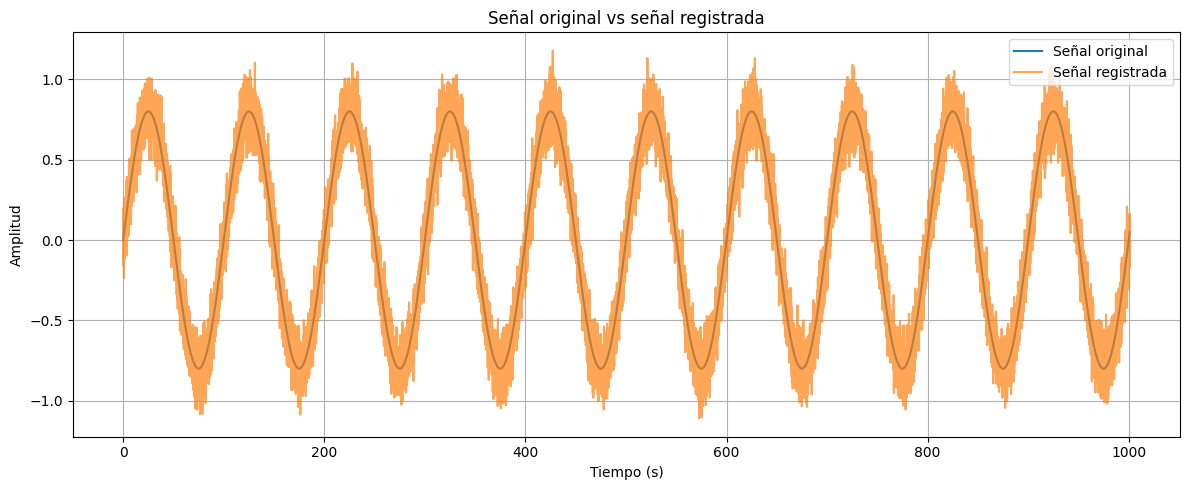

In [33]:
import numpy as np
import matplotlib.pyplot as plt

# Parámetros de la señal
fs = 25  # Frecuencia de muestreo (Hz)
f = 0.01    # Frecuencia de la señal (Hz)
alpha = 0.8  # Amplitud original
D = 15    # Número de muestras de retraso
n = np.arange(0, 1001, 1/fs)

# Señal original
x = alpha * np.sin(2 * np.pi * f * n)

# Ruido gaussiano
m = np.random.normal(0, 0.1, len(n))  # media=0, varianza=0.01

# Señal retrasada
x_e = np.zeros_like(x)
x_e[D:] = x[:-D]

# Señal con ruido y retraso (señal registrada)
y_e = x_e + m

# Graficar señales
plt.figure(figsize=(12, 5))
plt.plot(n, x, label='Señal original')
plt.plot(n, y_e, label='Señal registrada', alpha=0.7)
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.title("Señal original vs señal registrada")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()


# Diseño de filtros digitales

## Filtros FIR usando la función *firwin*


filtro FIR pasa bajas para la señal $𝑦_𝑒(𝑛)$, con una frecuencia de corte de 1.25 muestras/s y orden 30.


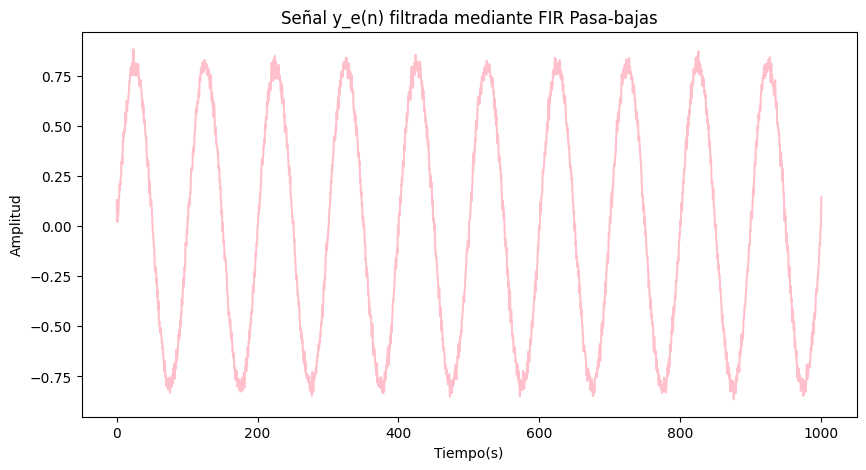

In [3]:
import scipy.signal as signal

# Definir parámetros del filtro
fc_pb = 1.25  # Frecuencia de corte en Hz
orden_fir = 30
nyquist = fs / 2
Wn_pb = fc_pb / nyquist  # Frecuencia normalizada

# Diseño del filtro pasa bajas FIR
fir_pb = signal.firwin(numtaps=orden_fir + 1, cutoff=Wn_pb, window='hamming')

#filtrado de la señal
y_e_fpb=signal.filtfilt(b=fir_pb,a=1,x=y_e) # Aplicación del filtro

# Graficamos
plt.figure(figsize=(10, 5))
plt.plot(n,y_e_fpb,color='pink')
plt.xlabel("Tiempo(s)")
plt.ylabel("Amplitud")
plt.title("Señal y_e(n) filtrada mediante FIR Pasa-bajas")

plt.show()


Filtro FIR pasa altas para la señal $𝑦_𝑒(𝑛)$, con una frecuencia de corte de 1.25 y 7.5 muestras/s y orden 30.


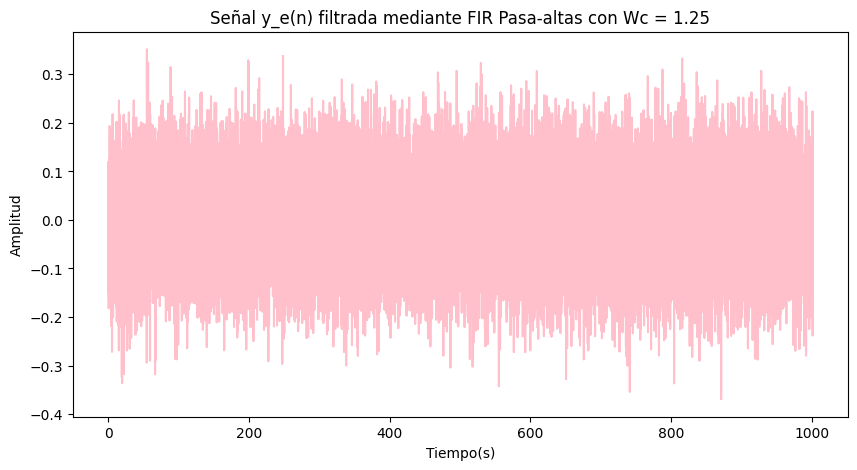

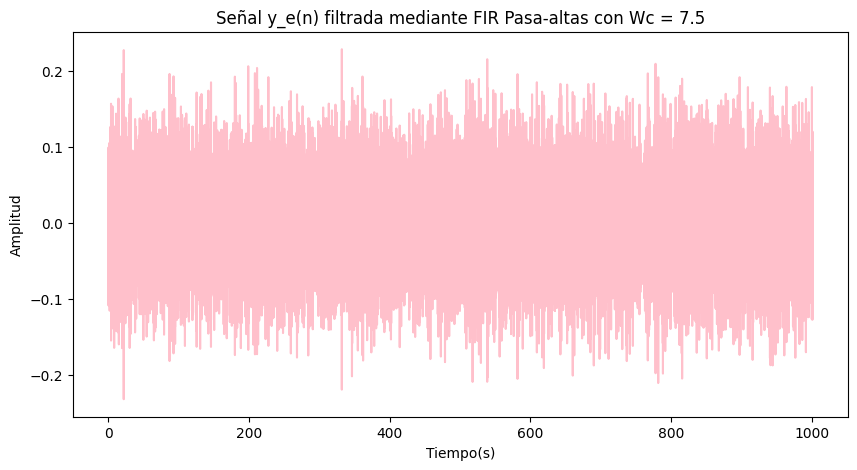

In [4]:
# Frecuencia de corte para pasa altas
fc_pa = [1.25, 7.5]
for f in fc_pa:
  Wn_pa = [f / nyquist]

  # Diseño del filtro pasa altas FIR
  fir_pa = signal.firwin(numtaps=orden_fir + 1, cutoff=Wn_pa, window='hamming', pass_zero=False)

  #filtrado de la señal
  y_e_fpa=signal.filtfilt(b=fir_pa,a=1,x=y_e) # Aplicación del filtro
  # Graficamos
  plt.figure(figsize=(10, 5))
  plt.plot(n,y_e_fpa,color='pink')
  plt.xlabel("Tiempo(s)")
  plt.ylabel("Amplitud")
  plt.title("Señal y_e(n) filtrada mediante FIR Pasa-altas con Wc = " + str(f))

  plt.show()


Filtro FIR pasa banda para la señal $𝑦_𝑒(𝑛)$, con una frecuencia de corte de 1.25 y 7.5 muestras/s y orden 30.


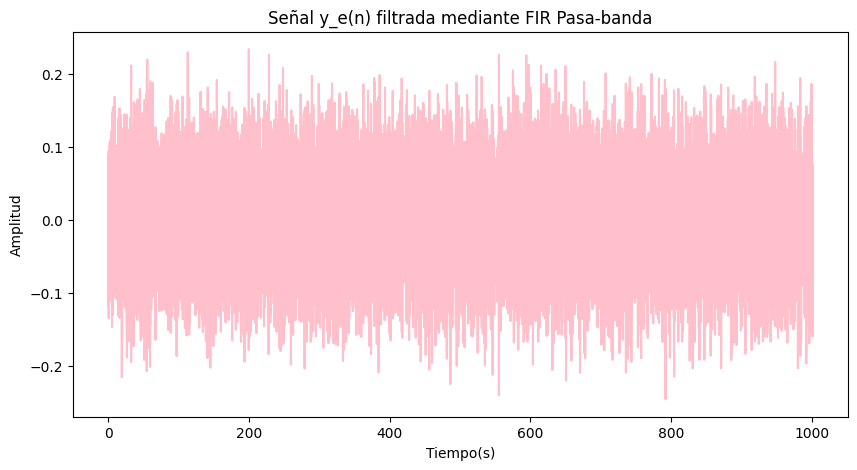

In [5]:
# Rango de frecuencias para el filtro pasa banda
fc_inferior = 1.25
fc_superior = 7.5

# Diseño del filtro pasa banda FIR
Wn_pbanda = [fc_inferior / nyquist, fc_superior / nyquist]


# Diseño del filtro pasa banda FIR
fir_pbanda = signal.firwin(numtaps=orden_fir + 1, cutoff=[Wn_pbanda[0], Wn_pbanda[1]], window='hamming', pass_zero=False)

#filtrado de la señal
y_e_fpbanda=signal.filtfilt(b=fir_pbanda,a=1,x=y_e) # Aplicación del filtro

# Graficamos
plt.figure(figsize=(10, 5))
plt.plot(n,y_e_fpbanda,color='pink')
plt.xlabel("Tiempo(s)")
plt.ylabel("Amplitud")
plt.title("Señal y_e(n) filtrada mediante FIR Pasa-banda")

plt.show()



## Comparación de la señal registrada y la señal filtrada


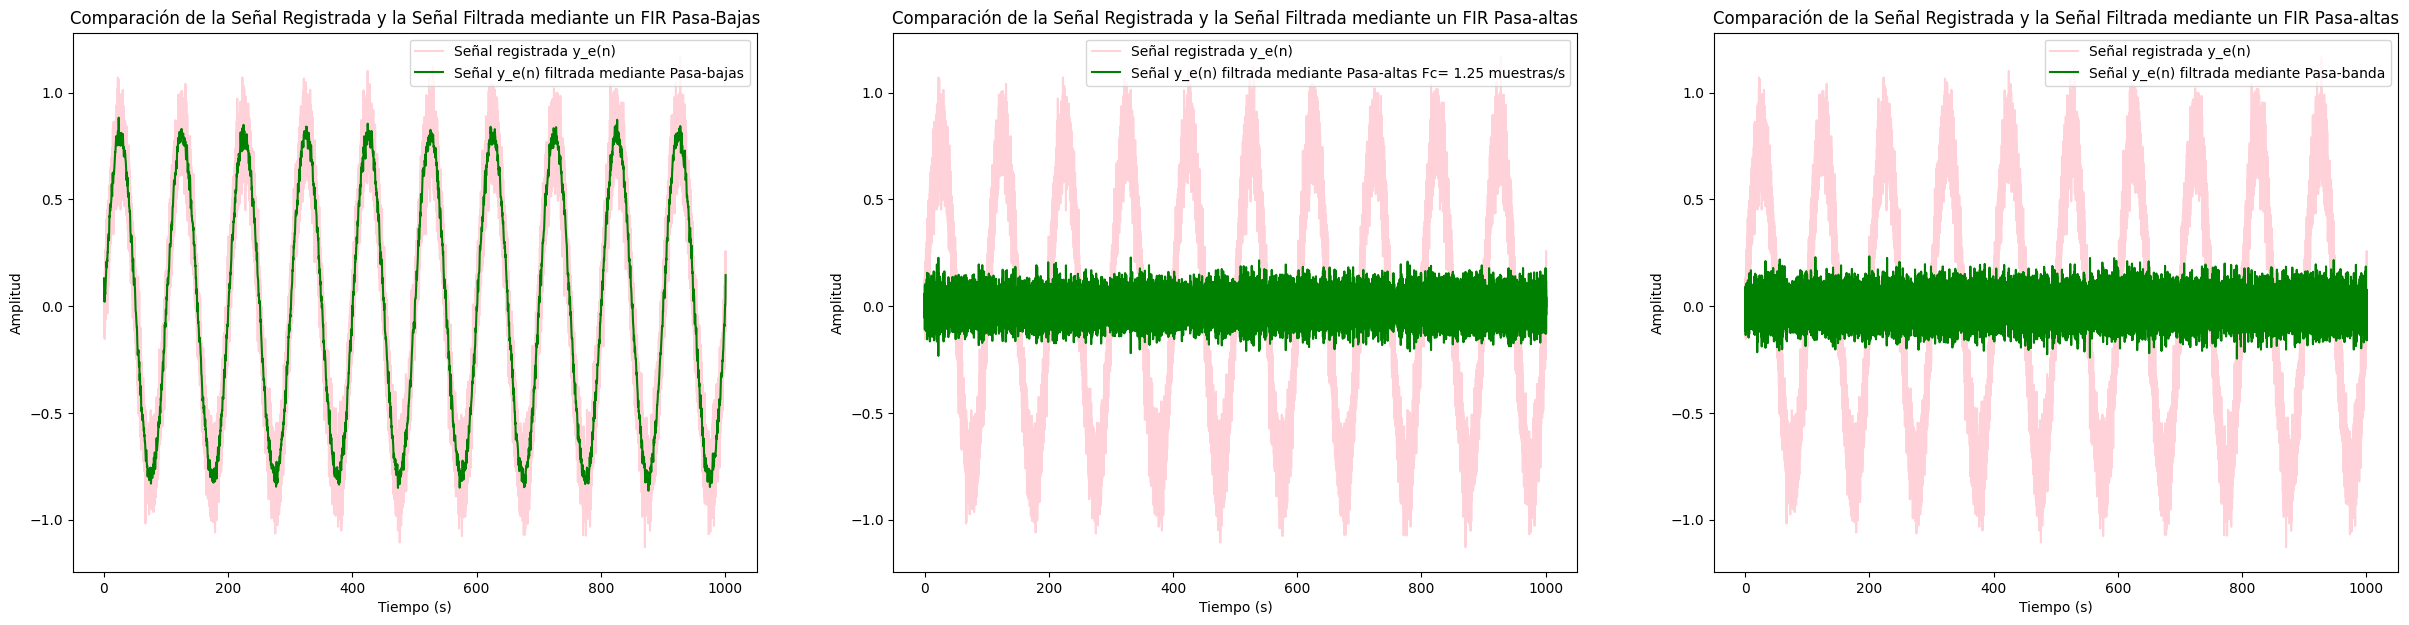

In [6]:
plt.figure(figsize=(30, 7))

plt.subplot(1,3,1)
plt.plot(n, y_e, label='Señal registrada y_e(n)', color='pink', alpha=0.7)
plt.plot(n, y_e_fpb, label='Señal y_e(n) filtrada mediante Pasa-bajas', color='green')
plt.title('Comparación de la Señal Registrada y la Señal Filtrada mediante un FIR Pasa-Bajas')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.legend()

plt.subplot(1,3,2)

plt.plot(n, y_e, label='Señal registrada y_e(n)', color='pink', alpha=0.7)
plt.plot(n, y_e_fpa, label='Señal y_e(n) filtrada mediante Pasa-altas Fc= 1.25 muestras/s', color='green')
plt.title('Comparación de la Señal Registrada y la Señal Filtrada mediante un FIR Pasa-altas')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.legend()

plt.subplot(1,3,3)

plt.plot(n, y_e, label='Señal registrada y_e(n)', color='pink', alpha=0.7)
plt.plot(n, y_e_fpbanda, label='Señal y_e(n) filtrada mediante Pasa-banda', color='green')
plt.title('Comparación de la Señal Registrada y la Señal Filtrada mediante un FIR Pasa-altas')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.legend()



plt.show()

**¿Qué cambios hay en los argumentos de la función para implementar un filtro pasa banda y pasa altas? Pruebe con una frecuencia de corte adicional de 7.5 muestras?**

Para implementar filtros pasa altas y pasa banda se debe ajustar el parámetro pass_zero a 'highpass' o 'bandpass' y para el filtro pasa bandas definifir las dos frecuencias de corte en el parámetro cutoff.

La señal filtrada con el pasa bajas muestra menor atenuación porque conserva la frecuencia fundamental de la señal original (0.01 Hz), que concentra la mayor parte de su energía. En cambio, los filtros pasa altas y pasa banda eliminan esta componente, dejando principalmente el ruido.  La señal de salida del filtro pasa banda tiene menor amplitud que la del pasa altas, ya que su rango de paso es más estrecho, lo que atenúa más las frecuencias altas.

## Filtros IIR usando la función *iirfilter*

Filtro IIR pasa bajas para la señal $𝑦_𝑒(𝑛)$, con una frecuencia de corte de 1.25 muestras/s y orden 30.

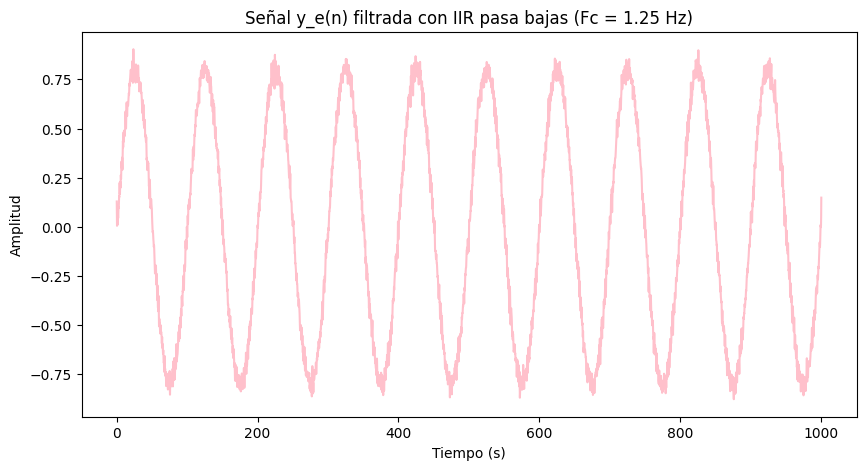

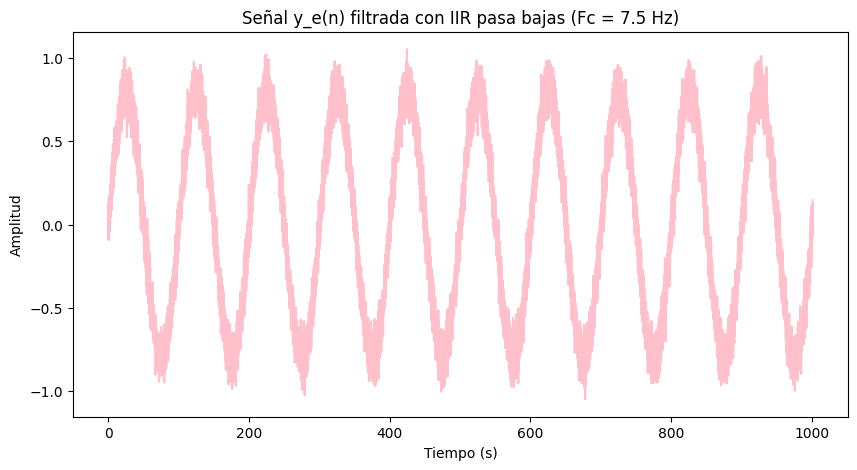

In [11]:
fc_pb = [1.25, 7.5]  # Frecuencias de corte en Hz para pruebas individuales
orden_iir = 4
nyquist = fs / 2

for f in fc_pb:
    Wn_pb = f / nyquist  # Frecuencia normalizada

    # Diseño del filtro pasa bajas IIR para cada frecuencia
    b_iir_pb, a_iir_pb = signal.iirfilter(orden_iir, Wn_pb, btype='low', ftype='butter')

    # Filtrado de la señal
    y_e_ipb = signal.filtfilt(b=b_iir_pb, a=a_iir_pb, x=y_e)

    # Graficamos
    plt.figure(figsize=(10, 5))
    plt.plot(n, y_e_ipb, color='pink')
    plt.xlabel("Tiempo (s)")
    plt.ylabel("Amplitud")
    plt.title(f"Señal y_e(n) filtrada con IIR pasa bajas (Fc = {f} Hz)")
    plt.show()


Filtro IIR pasa altas para la señal $𝑦_𝑒(𝑛)$, con una frecuencia de corte de 1.25 y 7.5 muestras/s y orden 30.

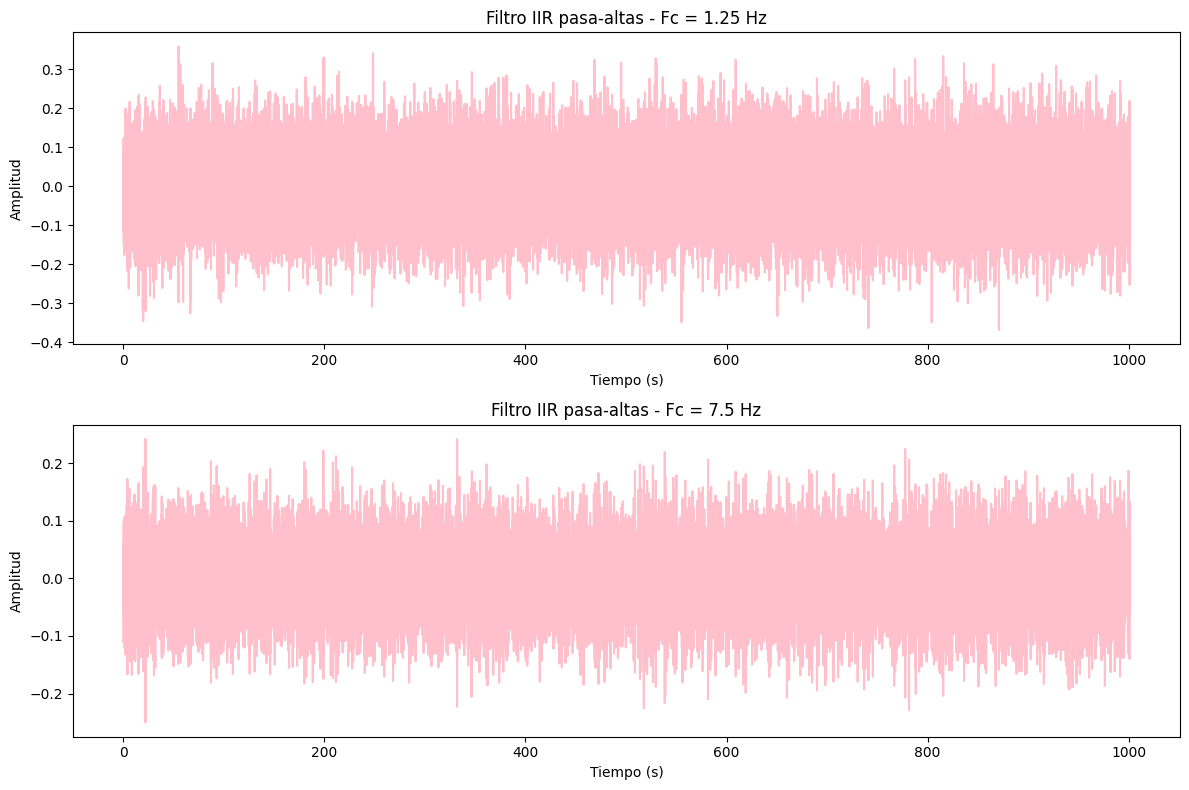

In [14]:
# Definir parámetros del filtro
fc_pa = [1.25, 7.5]  # Frecuencia de corte en Hz
orden_iir = 6        # Se recomienda orden más bajo para IIR
nyquist = fs / 2

plt.figure(figsize=(12, 4 * len(fc_pa)))  # Ajuste del tamaño de la figura

for i, f in enumerate(fc_pa):
    Wn_pa = f / nyquist  # Frecuencia normalizada

    # Diseño del filtro pasa altas IIR
    b_iir_pa, a_iir_pa = signal.iirfilter(orden_iir, Wn_pa, btype='high', ftype='butter')

    # Filtrado de la señal
    y_e_ipa = signal.filtfilt(b=b_iir_pa, a=a_iir_pa, x=y_e)

    # Graficamos en subplots
    plt.subplot(len(fc_pa), 1, i + 1)
    plt.plot(n, y_e_ipa, color='pink')
    plt.xlabel("Tiempo (s)")
    plt.ylabel("Amplitud")
    plt.title(f"Filtro IIR pasa-altas - Fc = {f} Hz")


plt.tight_layout()
plt.show()


Filtro IIR pasa banda para la señal $𝑦_𝑒(𝑛)$, con una frecuencia de corte de 1.25 y 7.5 muestras/s y orden 30.

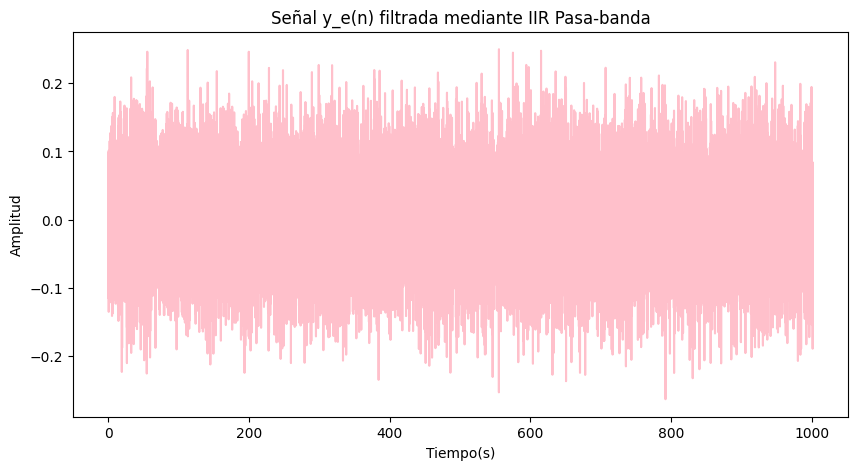

In [18]:
# Rango de frecuencias para el filtro pasa banda IIR
fc_inferior_iir = 1.25
fc_superior_iir = 7.5

# Frecuencias normalizadas para el filtro pasa banda IIR
Wn_pbanda_iir = [fc_inferior_iir / nyquist, fc_superior_iir / nyquist]

# Diseño del filtro pasa banda IIR
b_iir_pbanda, a_iir_pbanda = signal.iirfilter(orden_iir, Wn_pbanda_iir, ftype='butter', btype='band')

# Filtrado de la señal
y_e_ipbanda = signal.filtfilt(b=b_iir_pbanda, a=a_iir_pbanda, x=y_e)

# Graficamos
plt.figure(figsize=(10, 5))
plt.plot(n, y_e_ipbanda, color='pink')
plt.xlabel("Tiempo(s)")
plt.ylabel("Amplitud")
plt.title("Señal y_e(n) filtrada mediante IIR Pasa-banda")
plt.show()

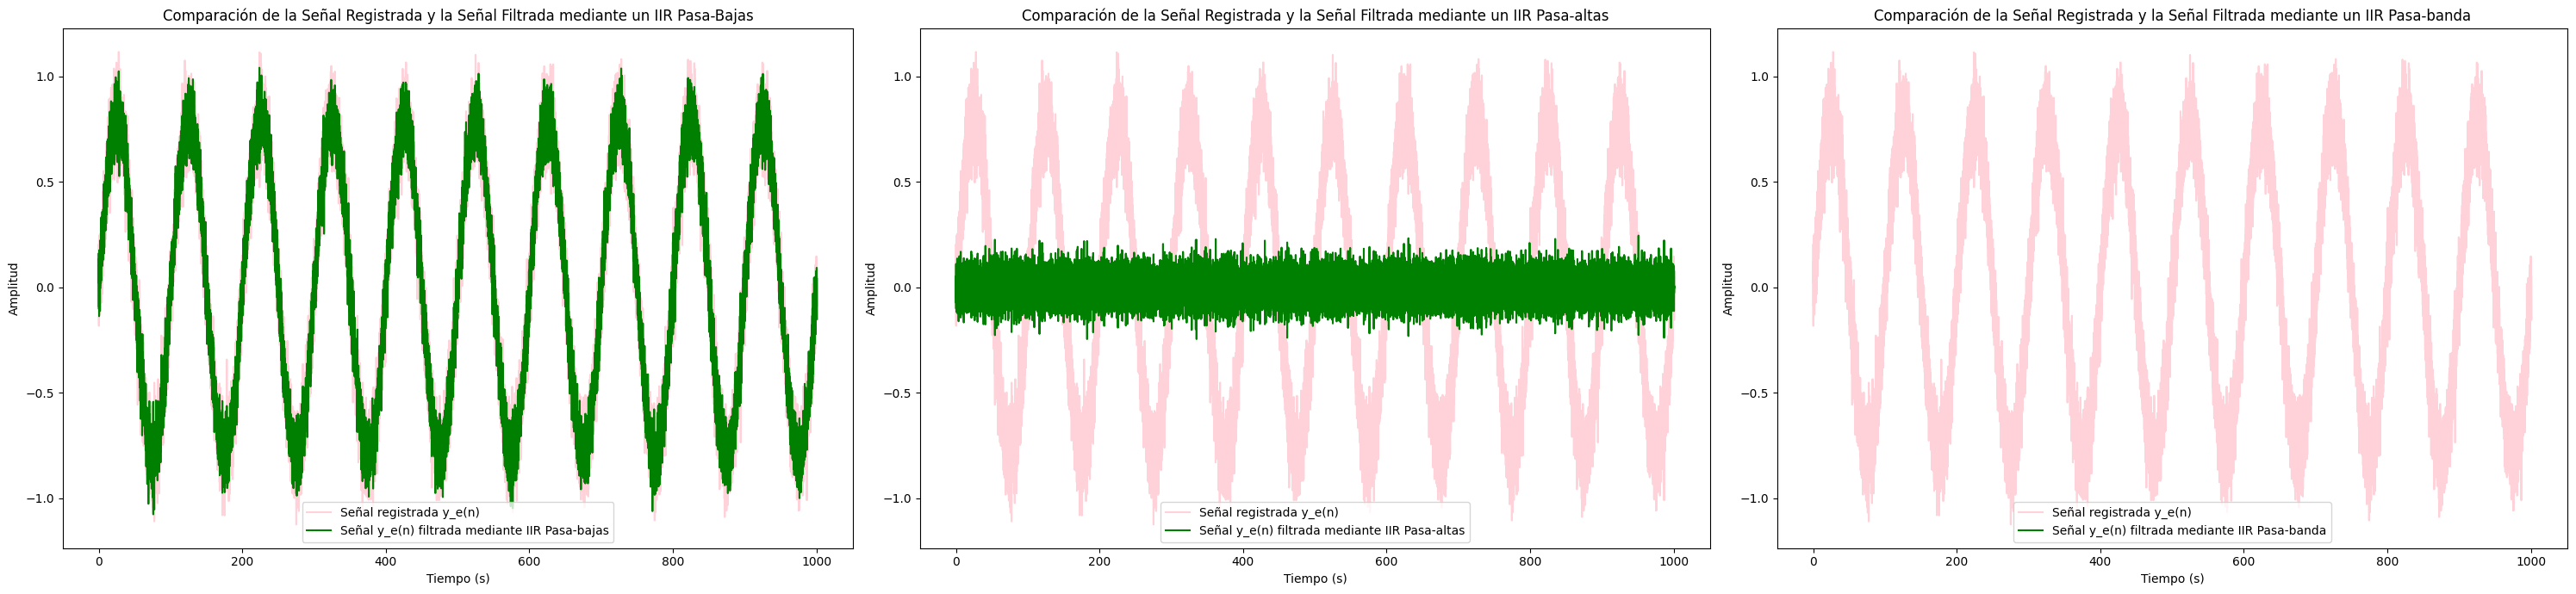

In [ ]:
plt.figure(figsize=(30, 7))

plt.subplot(1, 3, 1)
plt.plot(n, y_e, label='Señal registrada y_e(n)', color='pink', alpha=0.7)
plt.plot(n, y_e_ipb, label='Señal y_e(n) filtrada mediante IIR Pasa-bajas', color='green')
plt.title('Comparación de la Señal Registrada y la Señal Filtrada mediante un IIR Pasa-Bajas')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(n, y_e, label='Señal registrada y_e(n)', color='pink', alpha=0.7)
# Assuming y_e_ipa from the previous high-pass filter implementation for the first frequency
plt.plot(n, y_e_ipa, label='Señal y_e(n) filtrada mediante IIR Pasa-altas', color='green')
plt.title('Comparación de la Señal Registrada y la Señal Filtrada mediante un IIR Pasa-altas')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(n, y_e, label='Señal registrada y_e(n)', color='pink', alpha=0.7)
plt.plot(n, y_e_ipbanda, label='Señal y_e(n) filtrada mediante IIR Pasa-banda', color='green')
plt.title('Comparación de la Señal Registrada y la Señal Filtrada mediante un IIR Pasa-banda')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.legend()

plt.tight_layout()
plt.show()

# 4.3 lfilter y filtfilt con filtro FIR

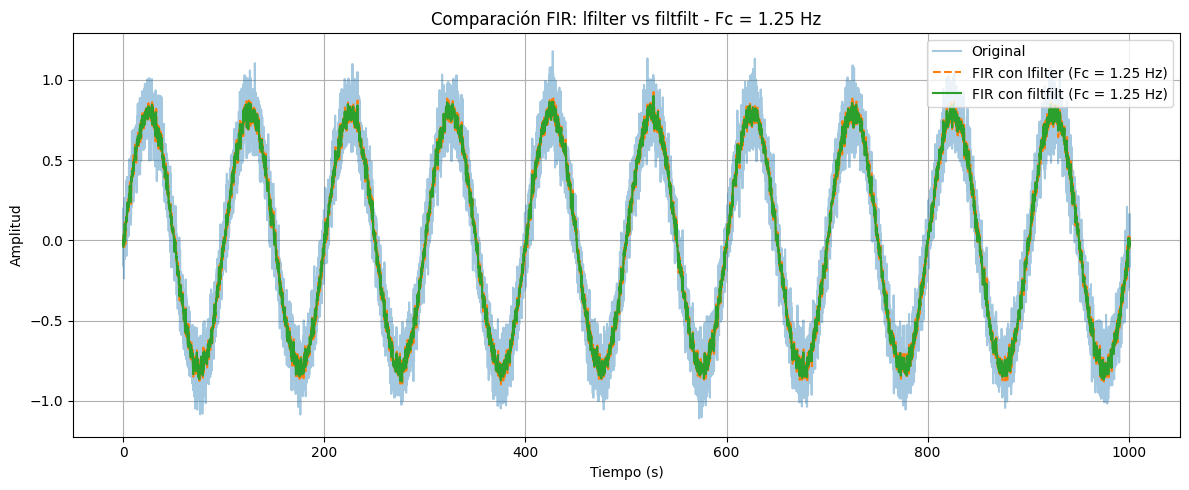

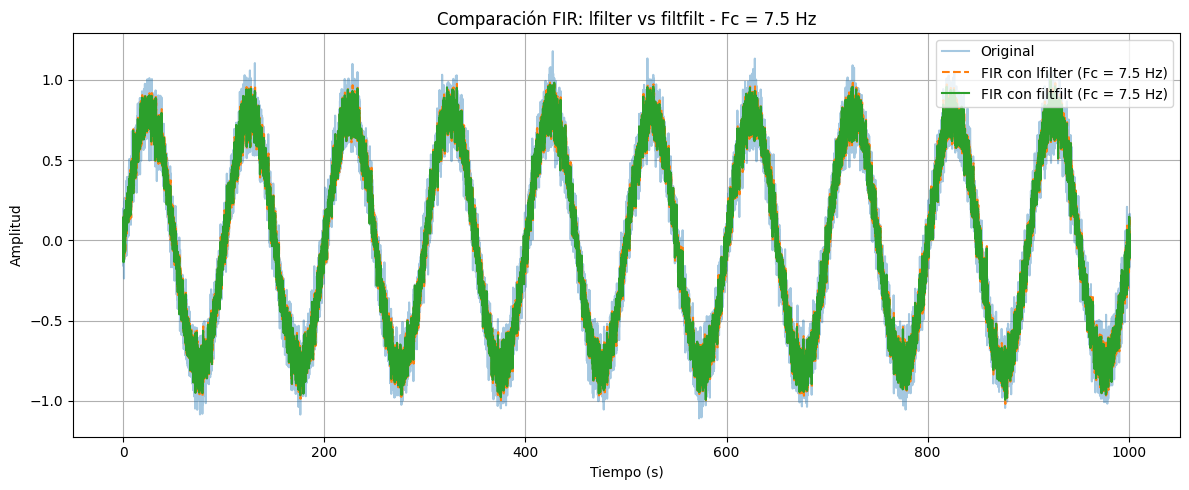

In [43]:
import scipy.signal as signal
import matplotlib.pyplot as plt

# Lista de frecuencias de corte para pruebas
fc_fir_list = [1.25, 7.5]  # Hz
orden_fir = 10
nyquist = fs / 2

# Iteramos sobre cada frecuencia de corte
for fc_fir in fc_fir_list:
    Wn_fir = fc_fir / nyquist  # Frecuencia normalizada

    # Diseño del filtro pasa bajas FIR con ventana de Hamming
    fir_pb = signal.firwin(numtaps=orden_fir + 1, cutoff=Wn_fir, window='hamming')

    # Aplicación del filtro con lfilter y filtfilt
    y_fir_lfilter = signal.lfilter(fir_pb, 1, y_e)
    y_fir_filtfilt = signal.filtfilt(fir_pb, 1, y_e)

    # Graficar resultados
    plt.figure(figsize=(12, 5))
    plt.plot(n, y_e, label='Original', alpha=0.4)
    plt.plot(n, y_fir_lfilter, label=f'FIR con lfilter (Fc = {fc_fir} Hz)', linestyle='--')
    plt.plot(n, y_fir_filtfilt, label=f'FIR con filtfilt (Fc = {fc_fir} Hz)', linestyle='-')
    plt.title(f"Comparación FIR: lfilter vs filtfilt - Fc = {fc_fir} Hz")
    plt.xlabel("Tiempo (s)")
    plt.ylabel("Amplitud")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()



¿Porque se utiliza solo el numerador?

Esto se debe a que los filtros FIR (Finite Impulse Response) son sistemas con una respuesta finita al impulso que no presentan realimentación; su estructura depende únicamente de valores actuales y pasados de la señal de entrada, y no de valores anteriores de la salida [1]. Por tanto, no requieren un denominador diferente de uno, ya que no tienen polos en su estructura y su implementación es inherentemente estable.

¿Evidencia cambios en el uso de las funciones de filtrado?

Al comparar las funciones de filtrado lfilter y filtfilt, se evidencian diferencias importantes en su comportamiento. La función lfilter aplica el filtro de forma directa en una única pasada sobre los datos, lo que introduce un desfase en la señal filtrada, especialmente evidente en filtros FIR de orden alto [2]. Por el contrario, filtfilt aplica el filtro dos veces: primero hacia adelante y luego hacia atrás, lo que anula el desfase de fase introducido por el filtro en la primera pasada [3]. En la gráfica proporcionada, se observa que ambas funciones suavizan la señal original, pero filtfilt genera una señal alineada temporalmente con la forma de onda original, preservando la morfología de la señal sin distorsión de fase.

¿Cómo se puede explicar la falta de coincidencia?

La falta de coincidencia entre los resultados de ambas funciones se explica por este comportamiento en fase. Mientras que lfilter introduce un retardo de grupo natural en filtros FIR, filtfilt lo compensa completamente, produciendo una señal con respuesta en fase cero [3]

¿Es adecuado el orden del filtro usado?

En cuanto al orden del filtro FIR utilizado (orden 10), se puede considerar adecuado para esta aplicación, especialmente al tratarse de una señal dominada por componentes de baja frecuencia. Un filtro FIR de este orden proporciona una respuesta suave y estable, lo que permite preservar la forma general de la señal útil sin introducir oscilaciones no deseadas ni distorsión significativa.

# lfilter y filtfilt con filtro IIR

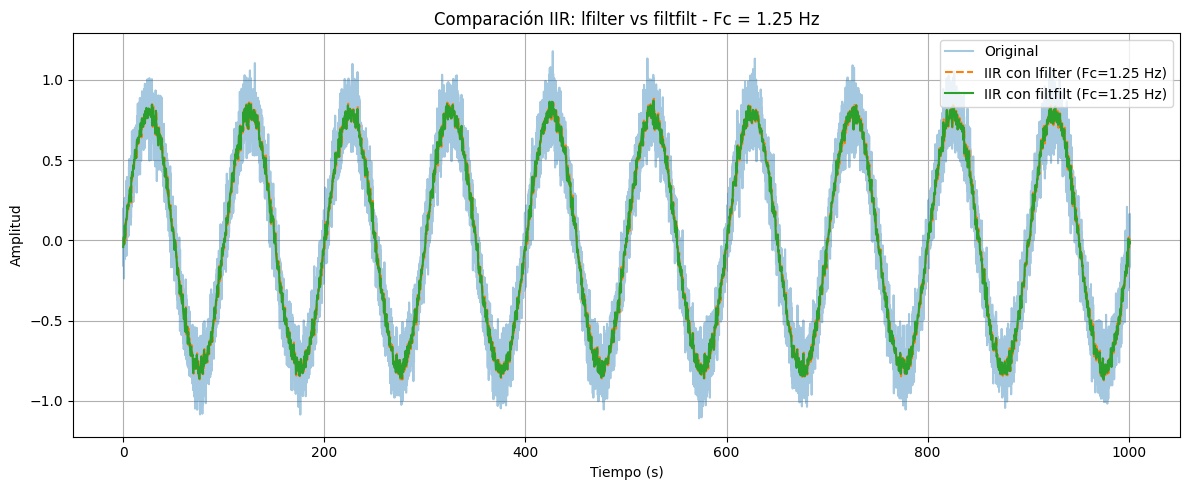

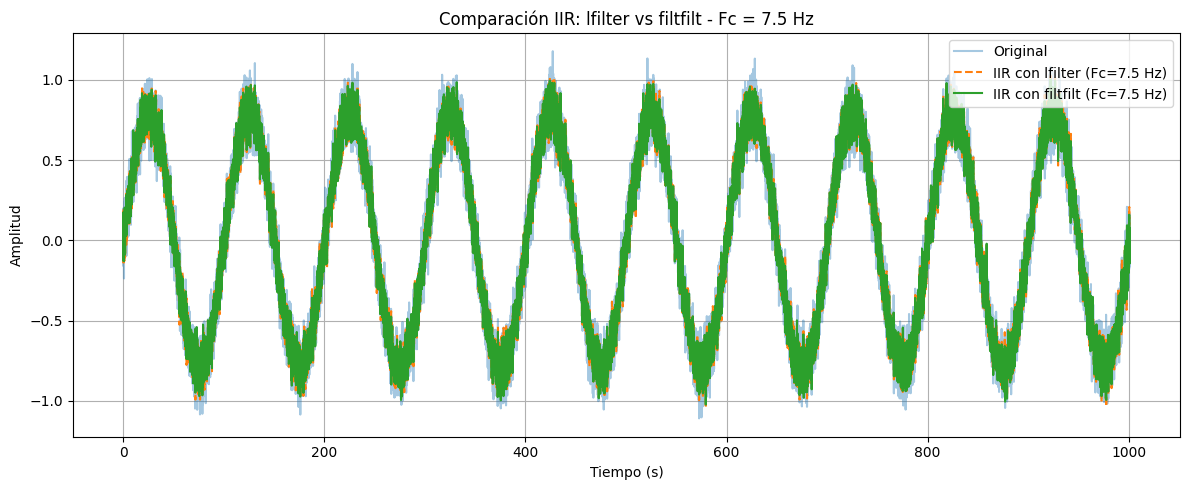

In [48]:
# Pruebas para filtro IIR pasa bajas con diferentes Fc
fc_iir_list = [1.25, 7.5]  # Hz
orden_iir = 4  # Más bajo que FIR, suficiente para IIR

for fc_iir in fc_iir_list:
    Wn_iir = fc_iir / nyquist

    # Diseño del filtro IIR pasa bajas Butterworth
    b_iir, a_iir = signal.iirfilter(orden_iir, Wn_iir, btype='low', ftype='butter')

    # Filtrado con lfilter y filtfilt
    y_iir_lfilter = signal.lfilter(b_iir, a_iir, y_e)
    y_iir_filtfilt = signal.filtfilt(b_iir, a_iir, y_e)

    # Graficamos
    plt.figure(figsize=(12, 5))
    plt.plot(n, y_e, label='Original', alpha=0.4)
    plt.plot(n, y_iir_lfilter, label=f'IIR con lfilter (Fc={fc_iir} Hz)', linestyle='--')
    plt.plot(n, y_iir_filtfilt, label=f'IIR con filtfilt (Fc={fc_iir} Hz)', linestyle='-')
    plt.title(f"Comparación IIR: lfilter vs filtfilt - Fc = {fc_iir} Hz")
    plt.xlabel("Tiempo (s)")
    plt.ylabel("Amplitud")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


¿Porque se utiliza el numerador y el denominador?

Esto se debe a que los filtros IIR (Infinite Impulse Response) tienen una estructura recursiva, es decir, su salida depende no solo de entradas pasadas sino también de salidas pasadas. El numerador representa los coeficientes de la parte no recursiva (feedforward), mientras que el denominador corresponde a la parte recursiva (feedback). Esta diferencia estructural exige un tratamiento más cuidadoso al aplicar el filtrado, ya que la presencia de polos en el plano Z puede introducir inestabilidad o efectos indeseados si no se maneja apropiadamente [1].

¿Es necesario cambiar el orden del filtro?

Al comparar los resultados obtenidos con órdenes más altos (por ejemplo, orden 15) frente a órdenes más bajos (como orden 4 o 6), se observa que un orden elevado puede producir inestabilidad o distorsión en la señal, especialmente si la frecuencia de corte está cerca de la frecuencia dominante del contenido útil.

# 4.4 Aplicacion

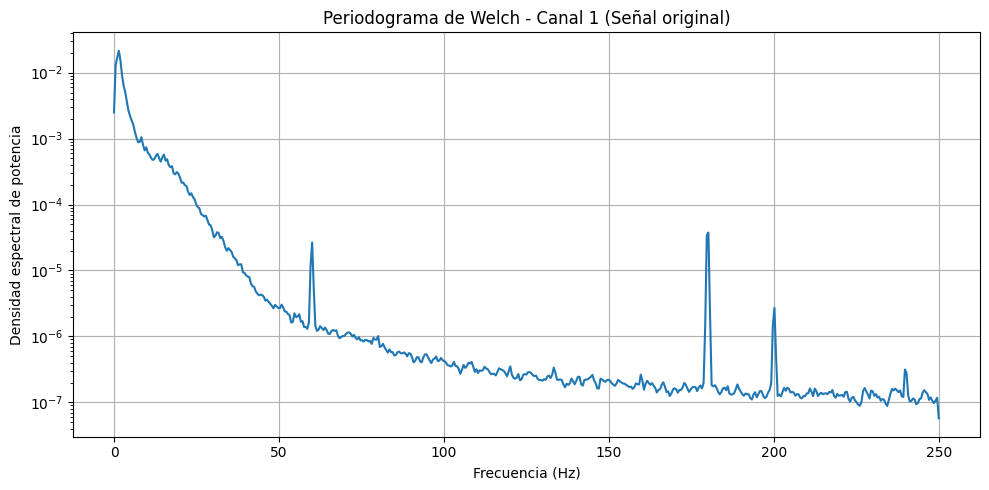

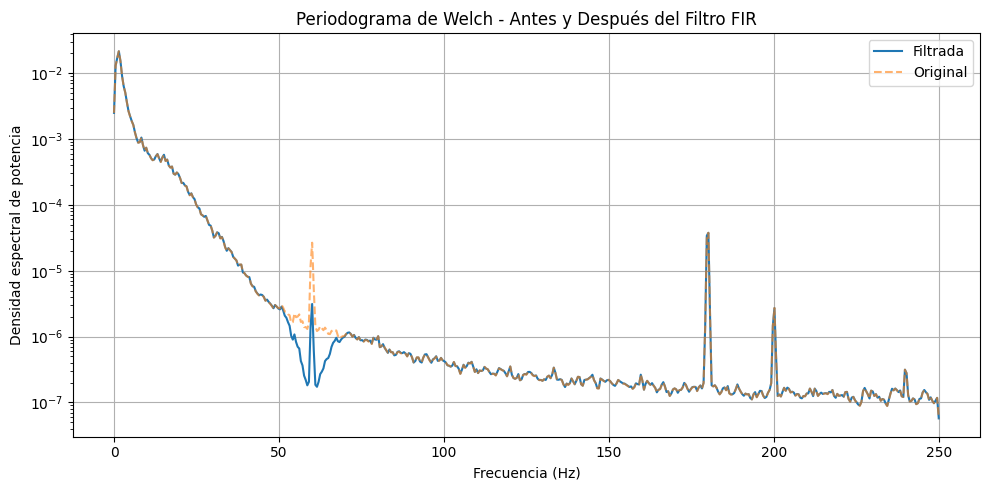

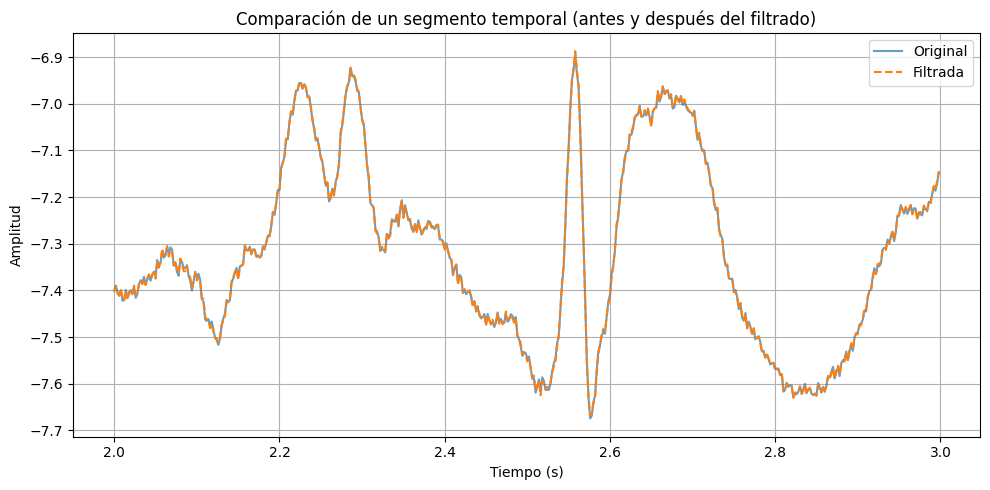

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# 1. Cargar la señal y extraer canal 1
fs = 500  # Frecuencia de muestreo (Hz)

# Cargar archivo .txt con múltiples columnas
data = np.loadtxt("/content/senal_filtros.txt")
canal_1 = data[:, 0]  # Canal 1
n = np.arange(len(canal_1)) / fs  # Vector de tiempo

# 2. Análisis frecuencial con periodograma de Welch
f, Pxx = signal.welch(canal_1, fs=fs, nperseg=1024)

plt.figure(figsize=(10, 5))
plt.semilogy(f, Pxx)
plt.title('Periodograma de Welch - Canal 1 (Señal original)')
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('Densidad espectral de potencia')
plt.grid(True)
plt.tight_layout()
plt.show()

# 3. Diseño del filtro FIR para eliminar ruido eléctrico (60 Hz)

# Suponiendo que hay ruido a 60 Hz y queremos eliminarlo
# Usamos un notch alrededor de 60 Hz

# Definimos un filtro FIR elimina banda
orden_fir = 100
band_stop = [58, 62]  # Banda a eliminar en Hz
wn_stop = [f / (fs / 2) for f in band_stop]  # Frecuencia normalizada

# Filtro FIR elimina banda
fir_bs = signal.firwin(numtaps=orden_fir + 1, cutoff=wn_stop, window='hamming', pass_zero=True)

# Aplicar el filtro
canal_1_filtrada = signal.filtfilt(fir_bs, 1, canal_1)


# 4. Nuevo análisis frecuencial con señal filtrada

f_filt, Pxx_filt = signal.welch(canal_1_filtrada, fs=fs, nperseg=1024)

plt.figure(figsize=(10, 5))
plt.semilogy(f_filt, Pxx_filt, label='Filtrada')
plt.semilogy(f, Pxx, '--', label='Original', alpha=0.6)
plt.title('Periodograma de Welch - Antes y Después del Filtro FIR')
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('Densidad espectral de potencia')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 5. Comparación visual de un segmento en el tiempo

segmento = slice(1000, 1500)  # Segmento de 1 segundo aprox

plt.figure(figsize=(10, 5))
plt.plot(n[segmento], canal_1[segmento], label='Original', alpha=0.7)
plt.plot(n[segmento], canal_1_filtrada[segmento], label='Filtrada', linestyle='--')
plt.title('Comparación de un segmento temporal (antes y después del filtrado)')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


¿Hay presencia de ruido eléctrico?

Observando el periodograma de welch se evidencia ruido eléctrico en la señal original. Se observa un pico muy pronunciado en 60 Hz (frecuencia típica de interferencia por la red eléctrica). Esto indica que la señal estaba contaminada por interferencia electromagnética proveniente de la red eléctrica.

¿Hay cambios despues del filtro FIR?
el filtro FIR diseñado logra eliminar exitosamente el ruido de 60 Hz. Esto se refleja en:

Una caída abrupta de la densidad espectral de potencia justo en los 60 Hz (visible en la línea azul – señal filtrada).

La curva filtrada se superpone casi completamente con la original en otras frecuencias, lo cual indica que el resto de la señal fue preservado.



# Conclusiones


*   El uso de la función filtfilt en filtros FIR e IIR es esencial cuando se desea preservar la alineación temporal de la señal original, ya que este método aplica el filtrado hacia adelante y hacia atrás. Esto resulta particularmente importante en el análisis de señales fisiológicas, donde incluso pequeños desfases pueden alterar la interpretación clínica o experimental de eventos temporales relevantes.
*   En filtros IIR, es necesario usar numerador y denominador por su estructura recursiva. Además, emplear un orden bajo (como 4 o 6) mejora la estabilidad y evita distorsiones que pueden surgir al aplicar filtfilt con órdenes elevados.


*   El análisis espectral mediante el periodograma de Welch permitió detectar el ruido eléctrico en la señal. Su uso antes y después del filtrado demostró ser una herramienta eficaz para validar la reducción del ruido sin afectar otras componentes relevantes de la señal.






# Referencias

[1] A. V. Oppenheim, R. W. Schafer y J. R. Buck, Discrete-Time Signal Processing, 2nd ed. Upper Saddle River, NJ, USA: Prentice Hall, 1999.

[2] S. W. Smith, The Scientist and Engineer's Guide to Digital Signal Processing, 2nd ed. California Technical Publishing, 1999.

[3] MATLAB Documentation, "filtfilt – Zero-phase digital filtering," MathWorks. [Online]. Available: https://www.mathworks.com/help/signal/ref/filtfilt.html